# CamemBERT comparison

This notebook loads the output of `scripts/camembert_analysis.py` and visualizes how the selected language model scores the standard and informal French sentence pairs.

In [43]:
from pathlib import Path

from IPython.display import display
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')

In [44]:
def find_analysis_csv() -> Path:
    candidates = [
        Path.cwd() / 'data' / 'paired_informal_french_dataset_camembert_analysis.csv',
        Path.cwd().parent / 'data' / 'paired_informal_french_dataset_camembert_analysis.csv',
    ]

    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()

    raise FileNotFoundError('Could not locate paired_informal_french_dataset_camembert_analysis.csv')

csv_path = find_analysis_csv()
df = pd.read_csv(csv_path)

if 'model_family' in df.columns and df['model_family'].notna().any():
    model_family = df['model_family'].dropna().iloc[0]
elif 'standard_nll_score' in df.columns and df['standard_nll_score'].notna().any():
    model_family = 'causal_lm'
else:
    model_family = 'masked_lm'

if model_family == 'causal_lm':
    score_name = 'NLL'
    standard_score_col = 'standard_nll_score'
    informal_score_col = 'informal_nll_score'
    higher_is_better = False
else:
    score_name = 'PLL'
    standard_score_col = 'standard_pll_score'
    informal_score_col = 'informal_pll_score'
    higher_is_better = True

df['score_gap'] = df[informal_score_col] - df[standard_score_col]
df['token_count_gap'] = df['informal_token_count'] - df['standard_token_count']

print(f'Loaded {len(df)} rows from {csv_path}')
print(f'Model family: {model_family} | primary score: {score_name}')
df.head()

Loaded 350 rows from /home/wan/github_project/llm_verlan/lang_informal/data/paired_informal_french_dataset_camembert_analysis.csv
Model family: masked_lm | primary score: PLL


,id,phenomenon,standard_sentence,informal_sentence,meaning_same,notes,standard_tokens,informal_tokens,standard_token_count,informal_token_count,standard_pll_score,informal_pll_score,standard_nll_score,informal_nll_score,standard_perplexity,informal_perplexity,representation_cosine_similarity,model_family,score_gap,token_count_gap
0,1,verlan,Je ne veux pas parler a cette femme ce soir.,Je veux pas parler a cette meuf ce soir.,1,synthetic balanced example; verlan/youth slang...,"['▁Je', '▁ne', '▁veux', '▁pas', '▁parler', '▁a...","['▁Je', '▁veux', '▁pas', '▁parler', '▁a', '▁ce...",11,11,-10.355141,-10.354279,NaN,NaN,NaN,NaN,0.960252,masked_lm,0.000862,0
1,2,verlan,Je ne vais pas a la fete de mon frere demain.,Je vais pas a la teuf de mon reuf demain.,1,synthetic balanced example; verlan/youth slang...,"['▁Je', '▁ne', '▁vais', '▁pas', '▁a', '▁la', '...","['▁Je', '▁vais', '▁pas', '▁a', '▁la', '▁te', '...",12,13,-10.636255,-10.354836,NaN,NaN,NaN,NaN,0.930353,masked_lm,0.281419,1
2,3,verlan,Je ne trouve pas ce type tres bizarre au fond.,Je trouve pas ce mec tres zarbi au fond.,1,synthetic balanced example; verlan/youth slang...,"['▁Je', '▁ne', '▁trouve', '▁pas', '▁ce', '▁typ...","['▁Je', '▁trouve', '▁pas', '▁ce', '▁mec', '▁tr...",11,12,-10.488177,-10.360942,NaN,NaN,NaN,NaN,0.958266,masked_lm,0.127235,1
3,4,verlan,Je ne peux pas laisser ce policier entrer dans...,Je peux pas laisser ce keuf entrer dans la zon...,1,synthetic balanced example; verlan/youth slang...,"['▁Je', '▁ne', '▁peux', '▁pas', '▁laisser', '▁...","['▁Je', '▁peux', '▁pas', '▁laisser', '▁ce', '▁...",12,14,-10.354384,-10.339363,NaN,NaN,NaN,NaN,0.895991,masked_lm,0.015021,2
4,5,verlan,Je ne supporte plus ce cours tres penible.,Je supporte plus ce cours trop relou.,1,synthetic balanced example; verlan/youth slang...,"['▁Je', '▁ne', '▁supporte', '▁plus', '▁ce', '▁...","['▁Je', '▁supporte', '▁plus', '▁ce', '▁cours',...",10,9,-10.425254,-10.374003,NaN,NaN,NaN,NaN,0.952775,masked_lm,0.051251,-1


In [45]:
summary_rows = [
    ('rows', len(df)),
    (f'mean standard {score_name}', df[standard_score_col].mean()),
    (f'mean informal {score_name}', df[informal_score_col].mean()),
    (f'mean {score_name} gap (informal - standard)', df['score_gap'].mean()),
    ('mean cosine similarity', df['representation_cosine_similarity'].mean()),
    ('mean token count gap (informal - standard)', df['token_count_gap'].mean()),
]

if model_family == 'causal_lm':
    summary_rows.extend(
        [
            ('mean standard perplexity', df['standard_perplexity'].mean()),
            ('mean informal perplexity', df['informal_perplexity'].mean()),
        ]
    )

summary = pd.DataFrame(summary_rows, columns=['metric', 'value'])

by_phenomenon = df.groupby('phenomenon', dropna=False).agg(
    pairs=('id', 'count'),
    mean_standard_score=(standard_score_col, 'mean'),
    mean_informal_score=(informal_score_col, 'mean'),
    mean_score_gap=('score_gap', 'mean'),
    mean_similarity=('representation_cosine_similarity', 'mean'),
    mean_token_gap=('token_count_gap', 'mean'),
)

if model_family == 'causal_lm':
    by_phenomenon = by_phenomenon.join(
        df.groupby('phenomenon', dropna=False).agg(
            mean_standard_perplexity=('standard_perplexity', 'mean'),
            mean_informal_perplexity=('informal_perplexity', 'mean'),
        )
    )

by_phenomenon = by_phenomenon.sort_values('mean_score_gap', ascending=not higher_is_better)

display(summary)
by_phenomenon

,metric,value
0,rows,350.000000
1,mean standard PLL,-10.441125
2,mean informal PLL,-10.391923
3,mean PLL gap (informal - standard),0.049202
4,mean cosine similarity,0.929508
5,mean token count gap (informal - standard),0.148571


,pairs,mean_standard_score,mean_informal_score,mean_score_gap,mean_similarity,mean_token_gap
phenomenon,,,,,,
verlan_sms_spoken,50,-10.441125,-10.368620,0.072505,0.894010,0.36
verlan_sms,50,-10.441125,-10.373917,0.067208,0.920710,0.20
verlan,50,-10.441125,-10.383426,0.057700,0.941544,0.88
verlan_spoken,50,-10.441125,-10.385771,0.055354,0.909443,1.04
sms_spoken,50,-10.441125,-10.391644,0.049481,0.924015,-0.72
spoken,50,-10.441125,-10.405165,0.035960,0.961368,-0.48
sms,50,-10.441125,-10.434920,0.006205,0.955464,-0.24


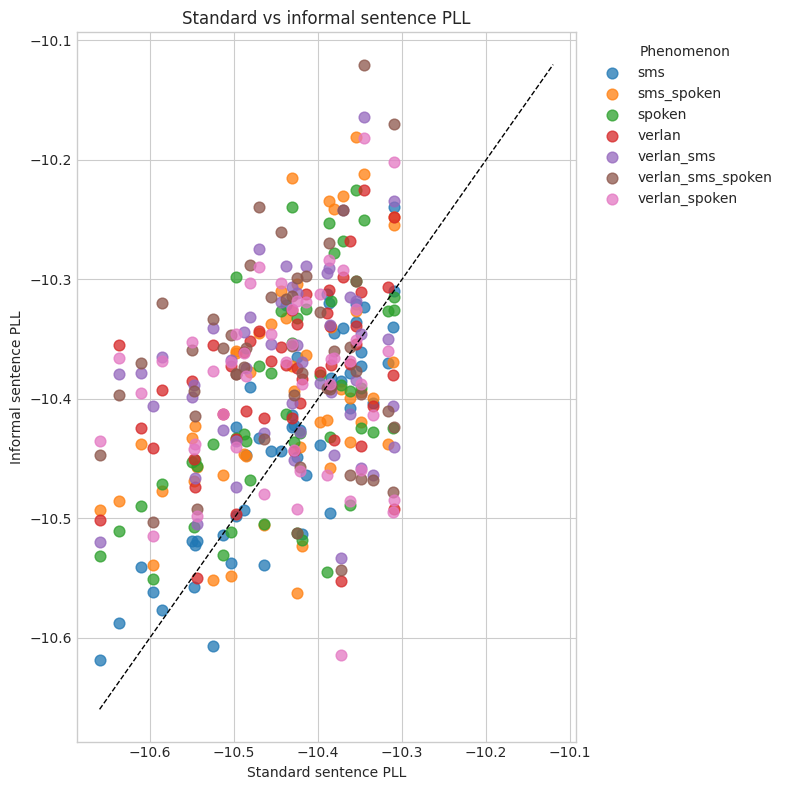

In [46]:
fig, ax = plt.subplots(figsize=(8, 8))

for phenomenon, group in df.groupby('phenomenon'):
    ax.scatter(
        group[standard_score_col],
        group[informal_score_col],
        label=phenomenon,
        alpha=0.75,
        s=60,
    )

lower = min(df[standard_score_col].min(), df[informal_score_col].min())
upper = max(df[standard_score_col].max(), df[informal_score_col].max())
ax.plot([lower, upper], [lower, upper], linestyle='--', color='black', linewidth=1)
ax.set_title(f'Standard vs informal sentence {score_name}')
ax.set_xlabel(f'Standard sentence {score_name}')
ax.set_ylabel(f'Informal sentence {score_name}')
ax.legend(title='Phenomenon', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

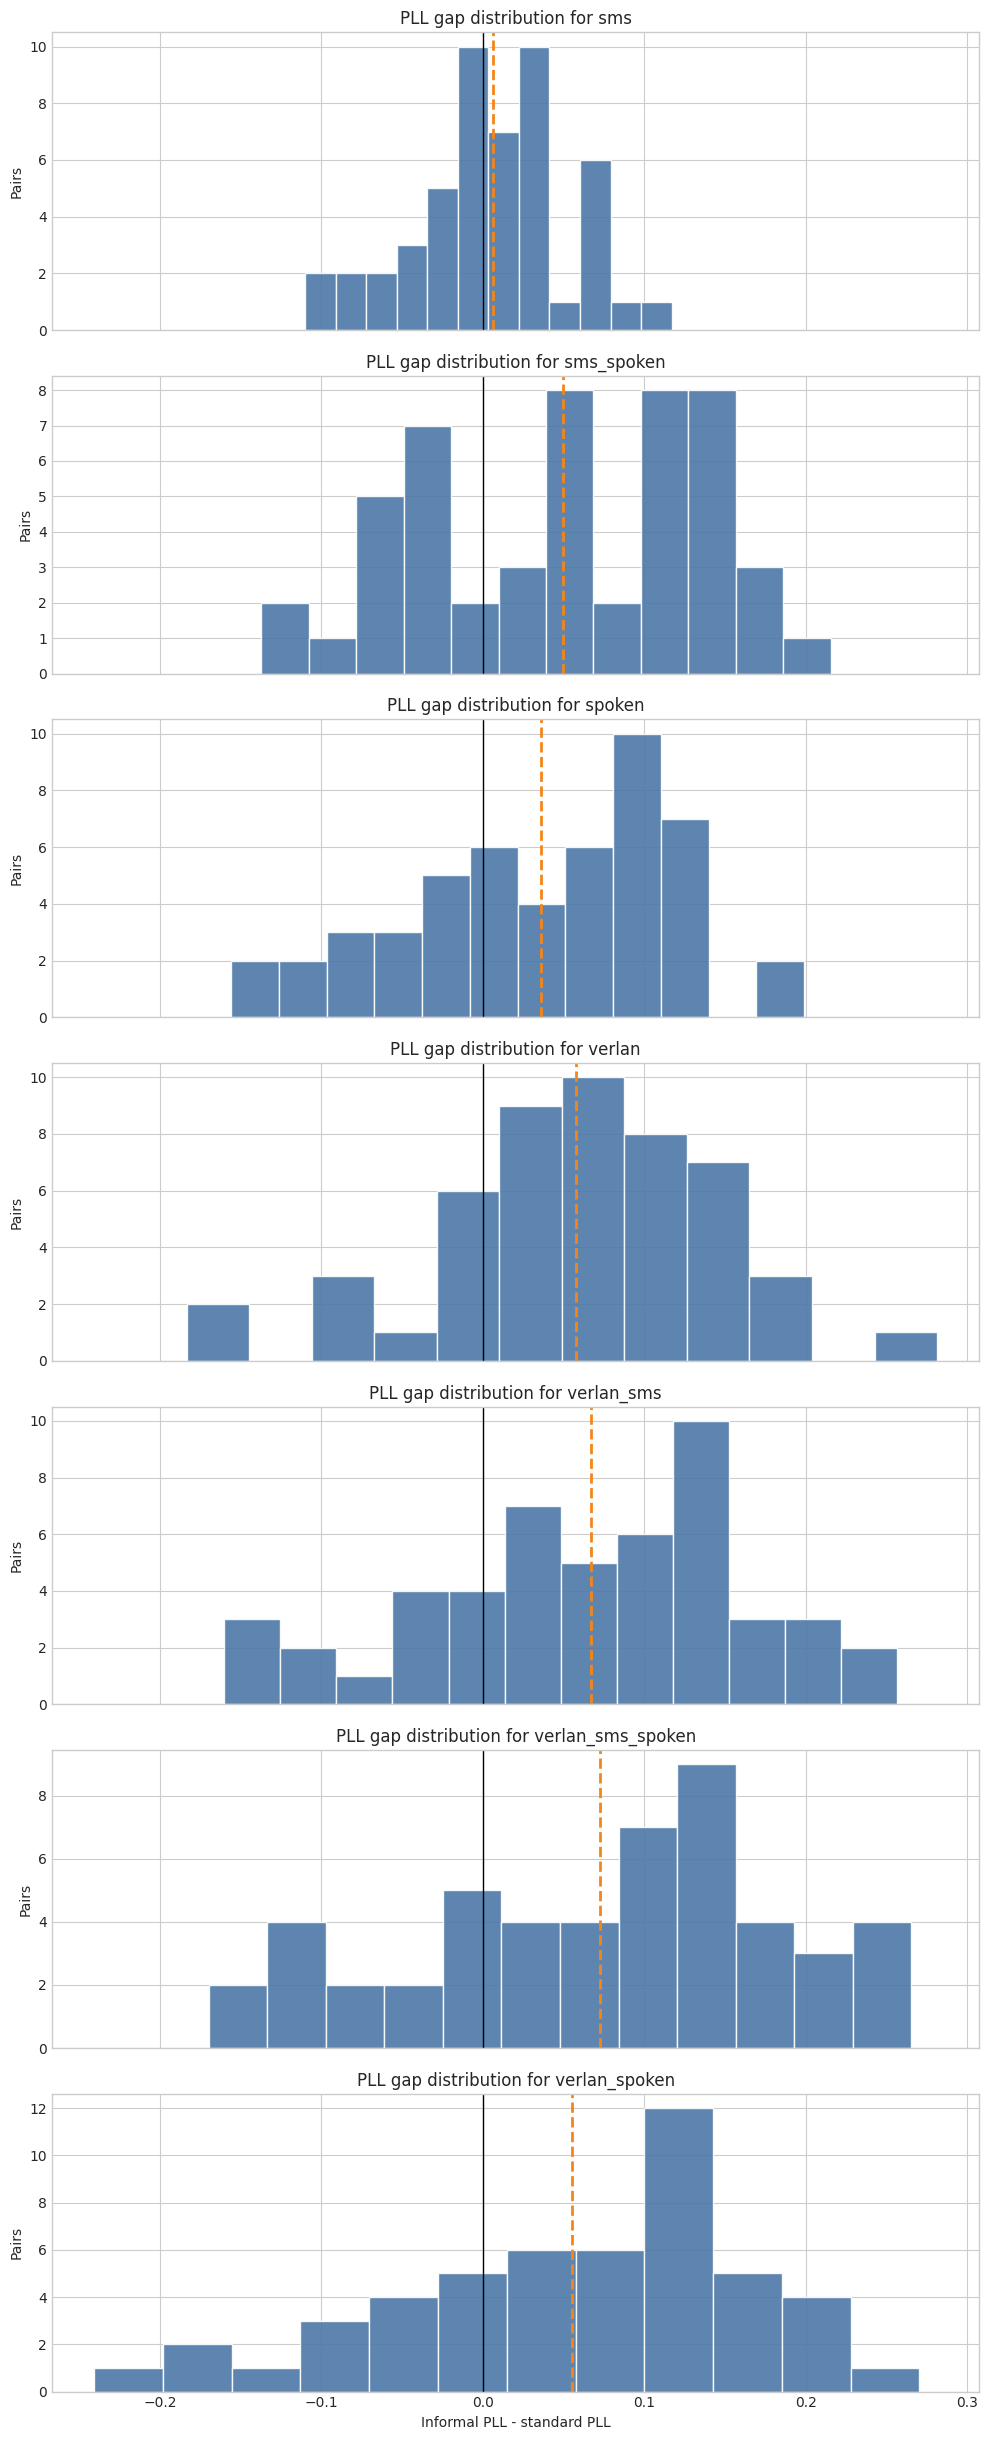

In [47]:
phenomena = sorted(df['phenomenon'].dropna().unique())
fig, axes = plt.subplots(len(phenomena), 1, figsize=(10, 3.5 * len(phenomena)), sharex=True)

if len(phenomena) == 1:
    axes = [axes]

for ax, phenomenon in zip(axes, phenomena):
    values = df.loc[df['phenomenon'] == phenomenon, 'score_gap']
    ax.hist(values, bins=12, color='#4C78A8', edgecolor='white', alpha=0.9)
    ax.axvline(values.mean(), color='#F58518', linestyle='--', linewidth=2)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_title(f'{score_name} gap distribution for {phenomenon}')
    ax.set_ylabel('Pairs')

axes[-1].set_xlabel(f'Informal {score_name} - standard {score_name}')
plt.tight_layout()
plt.show()

/tmp/ipykernel_45076/3879980085.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = ax.boxplot(data, labels=order, patch_artist=True)


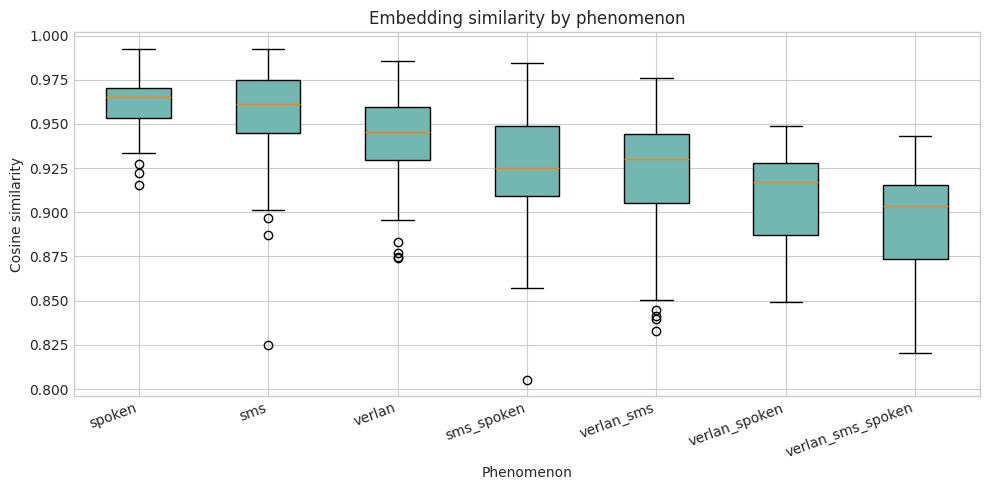

In [48]:
order = (
    df.groupby('phenomenon')['representation_cosine_similarity']
    .mean()
    .sort_values(ascending=False)
    .index
)

fig, ax = plt.subplots(figsize=(10, 5))
data = [
    df.loc[df['phenomenon'] == phenomenon, 'representation_cosine_similarity']
    for phenomenon in order
]

boxplot = ax.boxplot(data, labels=order, patch_artist=True)
for patch in boxplot['boxes']:
    patch.set_facecolor('#72B7B2')

ax.set_title('Embedding similarity by phenomenon')
ax.set_xlabel('Phenomenon')
ax.set_ylabel('Cosine similarity')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

In [49]:
ranking_columns = [
    'phenomenon',
    'standard_sentence',
    'informal_sentence',
    standard_score_col,
    informal_score_col,
    'score_gap',
    'representation_cosine_similarity',
]

if model_family == 'causal_lm':
    ranking_columns.extend(['standard_perplexity', 'informal_perplexity'])

if higher_is_better:
    most_informal_favored = df.nlargest(10, 'score_gap')[ranking_columns]
    most_standard_favored = df.nsmallest(10, 'score_gap')[ranking_columns]
else:
    most_informal_favored = df.nsmallest(10, 'score_gap')[ranking_columns]
    most_standard_favored = df.nlargest(10, 'score_gap')[ranking_columns]

print(f'Most favored informal sentences by {score_name}')
display(most_informal_favored)
print(f'Most favored standard sentences by {score_name}')
display(most_standard_favored)

Most favored informal sentences by PLL


,phenomenon,standard_sentence,informal_sentence,standard_pll_score,informal_pll_score,score_gap,representation_cosine_similarity
1,verlan,Je ne vais pas a la fete de mon frere demain.,Je vais pas a la teuf de mon reuf demain.,-10.636255,-10.354836,0.281419,0.930353
201,verlan_spoken,Je ne vais pas a la fete de mon frere demain.,J'vais pas a la teuf de mon reuf demain.,-10.636255,-10.365834,0.270421,0.917527
316,verlan_sms_spoken,Je ne peux pas parler a mon frere pendant le t...,J'peux pas parler a mon reuf pendant le taf,-10.585172,-10.319754,0.265418,0.903814
151,verlan_sms,Je ne vais pas a la fete de mon frere demain.,Je vais pas a la teuf de mon reuf dem1,-10.636255,-10.379412,0.256843,0.868806
348,verlan_sms_spoken,Je ne vais pas preter mon argent a cette femme.,J'vais pas preter ma thune a cette meuf,-10.610620,-10.370304,0.240317,0.915880
301,verlan_sms_spoken,Je ne vais pas a la fete de mon frere demain.,J'vais pas a la teuf de mon reuf dem1,-10.636255,-10.397135,0.239119,0.858421
198,verlan_sms,Je ne vais pas preter mon argent a cette femme.,Je vais pas preter ma thune a cette meuf,-10.610620,-10.377999,0.232622,0.935623
318,verlan_sms_spoken,Je ne veux pas donner ma voiture a ce policier.,J'veux pas donner ma caisse a ce keuf,-10.470210,-10.239788,0.230422,0.894579
313,verlan_sms_spoken,Je ne veux pas vendre ce materiel a ce type.,J'veux pas vendre ce matos a ce mec,-10.345075,-10.120374,0.224700,0.926835
225,verlan_spoken,Tu ne peux pas appeler la police maintenant.,T'peux pas appeler les keufs maintenant.,-10.659712,-10.435340,0.224372,0.876474


Most favored standard sentences by PLL


,phenomenon,standard_sentence,informal_sentence,standard_pll_score,informal_pll_score,score_gap,representation_cosine_similarity
236,verlan_spoken,Est-ce que tu peux calmer cette femme tres ene...,T'peux calmer cette meuf tres venere?,-10.373177,-10.613907,-0.240730,0.921380
233,verlan_spoken,Est-ce que tu vas laisser ton argent dans la m...,T'vas laisser ta thune dans la zonmai?,-10.310452,-10.494438,-0.183986,0.902013
47,verlan,Il y a une fete bizarre chez ce type.,Il y a une teuf chelou chez ce mec.,-10.309013,-10.492516,-0.183503,0.883183
36,verlan,Est-ce que tu peux calmer cette femme tres ene...,Est-ce que tu peux calmer cette meuf tres vene...,-10.373177,-10.552755,-0.179578,0.976811
247,verlan_spoken,Il y a une fete bizarre chez ce type.,Y a une teuf chelou chez ce mec.,-10.309013,-10.484873,-0.175860,0.862838
336,verlan_sms_spoken,Est-ce que tu peux calmer cette femme tres ene...,T'peux calmer cette meuf tres venere,-10.373177,-10.542970,-0.169793,0.913411
333,verlan_sms_spoken,Est-ce que tu vas laisser ton argent dans la m...,T'vas laisser ta thune dans la zonmai,-10.310452,-10.477807,-0.167356,0.873160
186,verlan_sms,Est-ce que tu peux calmer cette femme tres ene...,Est-ce que tu peux calmer cette meuf tres venere,-10.373177,-10.533387,-0.160210,0.969528
138,spoken,Est-ce que tu connais ce quartier vraiment biz...,T'connais ce quartier vraiment bizarre?,-10.388996,-10.544937,-0.155941,0.937440
254,sms_spoken,Je ne supporte plus ce cours tres penible.,J'supporte plus ce cours tres penible,-10.425254,-10.562414,-0.137160,0.956057
